# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

In [3]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             mean_absolute_error, mean_squared_error, r2_score)

SEED = 42  # semente fixa

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [4]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [5]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [6]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [7]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [8]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [9]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [10]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [11]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

---
# Análise — Tarefa 1 (Classificação)
## 1.1 Exploração dos dados

In [12]:
df_clf = pd.read_csv("aneel_classificacao_orange.csv", encoding="utf-8-sig")
print("Formato (linhas, colunas):", df_clf.shape)
df_clf.info()
print("\nValores ausentes por coluna:\n", df_clf.isna().sum())
print("\nContagem por classe:\n", df_clf["fonte"].value_counts())
print("\nProporção por classe:\n", df_clf["fonte"].value_counts(normalize=True).round(3))
df_clf.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].describe().T

Formato (linhas, colunas): (3876, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB

Valores ausentes por coluna:
 potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Contagem por classe:
 fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64

Proporção por classe:
 fonte
Hidráulica    0.381
Solar         0.310
Eólica        0.310
Name: proportion, dtype: float64


fonte                     Eólica    Hidráulica          Solar
potencia_kw count    1200.000000  1.476000e+03    1200.000000
            mean    30782.769883  7.580916e+04   11679.386733
            std     13800.597800  4.864196e+05   18374.855154
            min         0.160000  9.900000e-01       0.260000
            25%     23100.000000  9.900000e+02       1.000000
            50%     29600.000000  4.000000e+03       1.000000
            75%     37200.000000  1.700000e+04   28880.000000
            max    105000.000000  1.123310e+07  137480.000000
latitude    count    1200.000000  1.476000e+03    1200.000000
            mean       -9.896436 -2.111301e+01      -5.136029
            std         7.529853  6.500423e+00       5.546914
            min       -33.722806 -3.078799e+01     -29.835550
            25%       -11.136206 -2.675362e+01      -6.924585
            50%        -7.986274 -2.203073e+01      -2.055540
            75%        -5.271434 -1.760462e+01      -1.831473
            max         0.000000  3.801667e+00       3.831392
longitude   count    1200.000000  1.476000e+03    1200.000000
            mean      -39.715921 -4.893246e+01     -49.188463
            std         7.231867  7.976908e+00       5.912291
            min       -55.930850 -6.464614e+01     -69.941389
            25%       -41.865407 -5.263224e+01     -53.067800
            50%       -40.692088 -5.041888e+01     -52.440865
            75%       -36.491659 -4.619944e+01     -44.881156
            max         0.000000  0.000000e+00     -35.235400

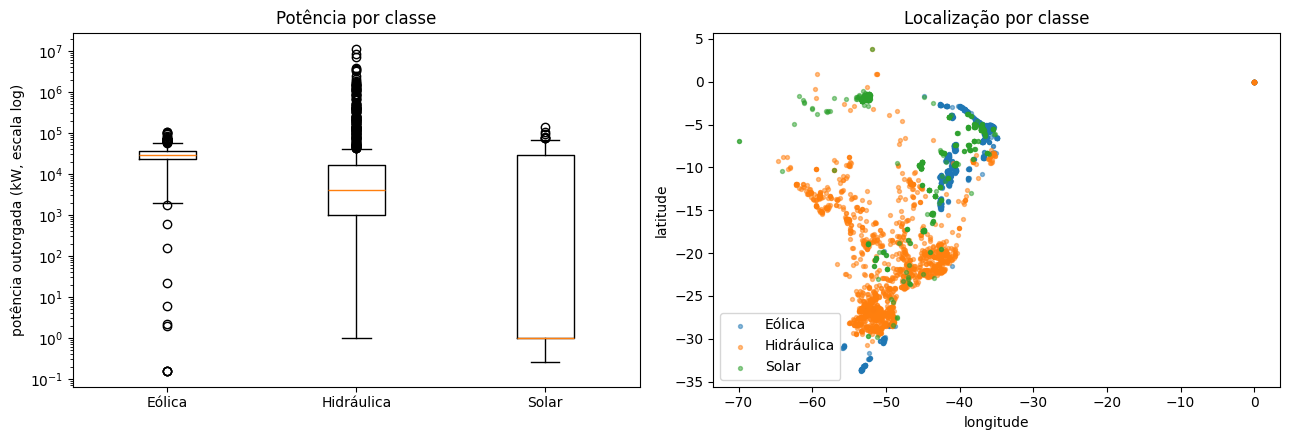

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
classes = sorted(df_clf["fonte"].unique())

# escala log porque a potência varia muito
axes[0].boxplot([df_clf.loc[df_clf["fonte"] == c, "potencia_kw"] for c in classes], tick_labels=classes)
axes[0].set_yscale("log"); axes[0].set_ylabel("potência outorgada (kW, escala log)")
axes[0].set_title("Potência por classe")

for c in classes:
    d = df_clf[df_clf["fonte"] == c]
    axes[1].scatter(d["longitude"], d["latitude"], s=8, alpha=0.5, label=c)
axes[1].set_xlabel("longitude"); axes[1].set_ylabel("latitude")
axes[1].set_title("Localização por classe"); axes[1].legend()
plt.tight_layout(); plt.show()

**Leitura da exploração.** A base tem 3.876 linhas e não tem valores ausentes. As classes têm tamanhos parecidos: Hidráulica tem 1.476 linhas (38,1%), Solar e Eólica têm 1.200 cada (31%). Um modelo que sempre chutasse Hidráulica acertaria 38,1%, e esse é o baseline.

A potência varia muito, de cerca de 1 kW até mais de 11 milhões de kW, então usei escala logarítmica no boxplot. A Eólica tem potências mais altas (mediana de uns 29,6 MW), a Hidráulica é a mais espalhada e a Solar tem mediana de só 1 kW. Pela localização, a Eólica fica mais no Nordeste, a Hidráulica no Sudeste e Sul e a Solar mais no Norte.

Sobre a amostra: a consulta pega no máximo 1.200 linhas por sigla, então não é uma amostra aleatória do Brasil. A Hidráulica veio quase completa (221 UHE, 537 PCH e 718 CGH), mas Solar e Eólica foram cortadas em 1.200. Também achei coisas estranhas: 62,8% das linhas Solar têm potência de até 1 kW, e 47 linhas (24 Eólica e 23 Hidráulica) têm latitude ou longitude igual a zero, que deve ser dado que estava faltando. Esses números foram calculados na seção 1.5. Como o código não descartou nenhuma linha, esses zeros ficaram na base.

## 1.2 Definição de X e y e divisão estratificada

In [14]:
X_clf = df_clf[["potencia_kw", "latitude", "longitude"]]
y_clf = df_clf["fonte"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.20, stratify=y_clf, random_state=SEED)

print("Treino:", Xc_train.shape, "| Teste:", Xc_test.shape)
print("\nProporção no treino:\n", yc_train.value_counts(normalize=True).round(3))
print("\nProporção no teste:\n", yc_test.value_counts(normalize=True).round(3))

Treino: (3100, 3) | Teste: (776, 3)

Proporção no treino:
 fonte
Hidráulica    0.381
Solar         0.310
Eólica        0.310
Name: proportion, dtype: float64

Proporção no teste:
 fonte
Hidráulica    0.381
Solar         0.309
Eólica        0.309
Name: proportion, dtype: float64


## 1.3 Treino dos três classificadores

Escolhi três algoritmos diferentes. O KNN olha os vizinhos mais próximos, o que faz sentido porque empreendimentos próximos tendem a ser da mesma fonte, mas ele depende da escala, então padronizei os dados. A Árvore de Decisão cria regras simples e é fácil de entender, mas pode decorar demais o treino (por isso limitei a profundidade em 8). O Random Forest usa várias árvores juntas, o que ajuda a evitar isso.

A padronização fica dentro de um `Pipeline`, então o `StandardScaler` usa só os dados de treino.

In [15]:
modelos_clf = {
    "KNN (k=5)": Pipeline([("scaler", StandardScaler()),
                           ("modelo", KNeighborsClassifier(n_neighbors=5))]),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=8, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED),
}

MEDIA = "macro"  # macro: mesmo peso para cada classe
resultados_clf, previsoes_clf = [], {}

for nome, modelo in modelos_clf.items():
    modelo.fit(Xc_train, yc_train)
    pred = modelo.predict(Xc_test)
    previsoes_clf[nome] = pred
    resultados_clf.append({
        "Algoritmo": nome,
        "Accuracy": accuracy_score(yc_test, pred),
        f"Precision ({MEDIA})": precision_score(yc_test, pred, average=MEDIA, zero_division=0),
        f"Recall ({MEDIA})": recall_score(yc_test, pred, average=MEDIA, zero_division=0),
        f"F1 ({MEDIA})": f1_score(yc_test, pred, average=MEDIA, zero_division=0),
        "F1 (weighted)": f1_score(yc_test, pred, average="weighted", zero_division=0),
    })

tabela_clf = pd.DataFrame(resultados_clf).set_index("Algoritmo").round(3)
print("Configuração: split 80/20 estratificado, seed =", SEED, "| média por classe:", MEDIA)
tabela_clf

Configuração: split 80/20 estratificado, seed = 42 | média por classe: macro


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Algoritmo,,,,,
KNN (k=5),0.965,0.966,0.964,0.965,0.965
Árvore de Decisão,0.937,0.937,0.933,0.934,0.936
Random Forest,0.976,0.977,0.974,0.975,0.975


In [16]:
# baseline (não conta como um dos três): sempre chuta a classe maior
base = DummyClassifier(strategy="most_frequent").fit(Xc_train, yc_train)
pb = base.predict(Xc_test)
print("Baseline classe majoritária -> Accuracy: %.3f | F1 macro: %.3f" %
      (accuracy_score(yc_test, pb), f1_score(yc_test, pb, average="macro", zero_division=0)))

Baseline classe majoritária -> Accuracy: 0.381 | F1 macro: 0.184


## 1.4 Matrizes de confusão

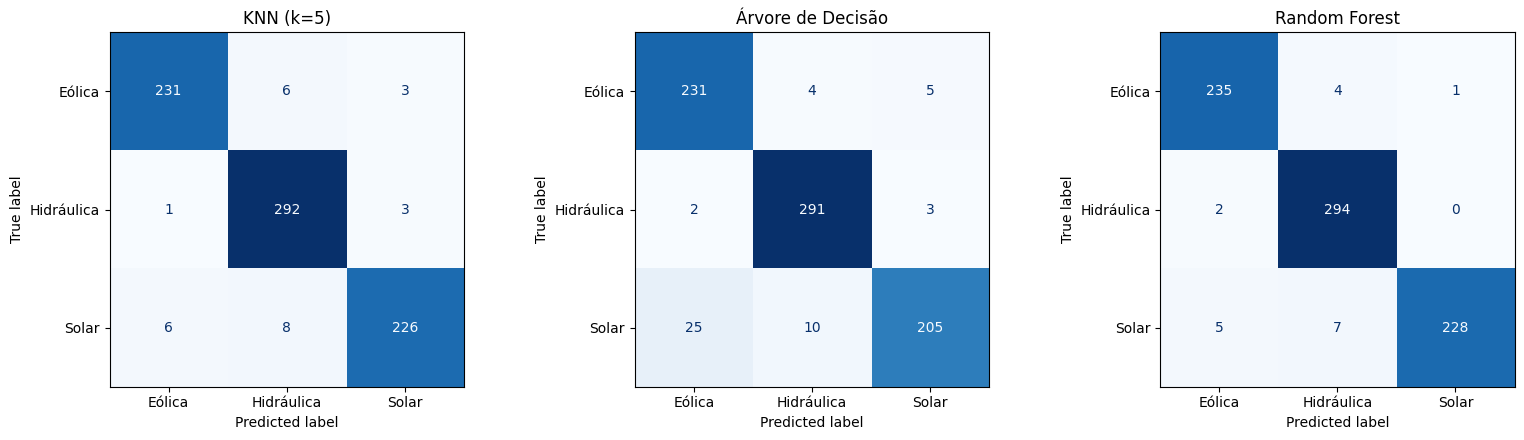

Relatório por classe do melhor modelo (F1 macro): Random Forest
              precision    recall  f1-score   support

      Eólica       0.97      0.98      0.98       240
  Hidráulica       0.96      0.99      0.98       296
       Solar       1.00      0.95      0.97       240

    accuracy                           0.98       776
   macro avg       0.98      0.97      0.98       776
weighted avg       0.98      0.98      0.98       776



In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nome, pred) in zip(axes, previsoes_clf.items()):
    ConfusionMatrixDisplay(confusion_matrix(yc_test, pred, labels=classes),
                           display_labels=classes).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nome)
plt.tight_layout(); plt.show()

melhor_clf = tabela_clf[f"F1 ({MEDIA})"].idxmax()
print("Relatório por classe do melhor modelo (F1 macro):", melhor_clf)
print(classification_report(yc_test, previsoes_clf[melhor_clf], zero_division=0))

In [ ]:
# erros do Random Forest na Solar, por faixa de potência
pred_rf = pd.Series(previsoes_clf["Random Forest"], index=Xc_test.index)
solar_teste = Xc_test[yc_test == "Solar"].copy()
solar_teste["errou"] = pred_rf[solar_teste.index] != "Solar"
solar_teste["faixa"] = pd.cut(solar_teste["potencia_kw"], [0, 1.01, 1000, 10000, 1e9],
                              labels=["até 1 kW", "1 a 1000 kW", "1 a 10 MW", "acima de 10 MW"])
print(solar_teste.groupby("faixa", observed=True)["errou"].agg(["sum", "count", "mean"]).round(3))
print("Para onde foram os erros:", pred_rf[solar_teste[solar_teste["errou"]].index].value_counts().to_dict())

                sum  count   mean
faixa                            
até 1 kW          0    159  0.000
1 a 1000 kW       5     10  0.500
1 a 10 MW         2      3  0.667
acima de 10 MW    5     68  0.074
Para onde foram os erros: {'Hidráulica': 7, 'Eólica': 5}


## 1.5 Diagnóstico da amostra e análise de sensibilidade

Na exploração vi coisas estranhas nos dados: muita Solar com cerca de 1 kW, coordenadas iguais a zero e classes que vieram de recortes diferentes. Os testes abaixo servem para ver se o bom resultado dos modelos vem de uma separação real entre as fontes ou desses problemas da amostra.

In [18]:
solar = df_clf[df_clf["fonte"] == "Solar"]
print("Solar com potência <= 1 kW:", round((solar["potencia_kw"] <= 1).mean(), 3))

zeros = (df_clf["latitude"] == 0) | (df_clf["longitude"] == 0)
print("Linhas com latitude ou longitude = 0:", int(zeros.sum()), df_clf[zeros]["fonte"].value_counts().to_dict())

print("\nFração de coordenadas repetidas por classe (arredondadas a 2 casas):")
print(df_clf.groupby("fonte")[["latitude", "longitude"]]
      .apply(lambda d: d.round(2).duplicated().mean()).round(3))

Solar com potência <= 1 kW: 0.628
Linhas com latitude ou longitude = 0: 47 {'Eólica': 24, 'Hidráulica': 23}

Fração de coordenadas repetidas por classe (arredondadas a 2 casas):
fonte
Eólica        0.038
Hidráulica    0.043
Solar         0.463
dtype: float64


In [ ]:
cols = ["potencia_kw", "latitude", "longitude"]
dup = df_clf[df_clf.duplicated(subset=cols, keep=False)]
print("Linhas idênticas nos 3 atributos (além da 1ª ocorrência):", int(df_clf.duplicated(subset=cols).sum()))
print("Por classe (todas as linhas envolvidas):", dup["fonte"].value_counts().to_dict())
print("Grupos duplicados com rótulos conflitantes:", int((df_clf.groupby(cols)["fonte"].nunique() > 1).sum()))

Linhas idênticas nos 3 atributos (além da 1ª ocorrência): 28
Por classe (todas as linhas envolvidas): {'Eólica': 20, 'Hidráulica': 16, 'Solar': 8}
Grupos duplicados com rótulos conflitantes: 0


In [19]:
from sklearn.base import clone

# mesmos modelos na base sem Solar <= 1 kW e sem coordenadas zero
filtro = ~zeros & ~((df_clf["fonte"] == "Solar") & (df_clf["potencia_kw"] <= 1))
df_filtrado = df_clf[filtro]
print("Linhas na base filtrada:", len(df_filtrado), "de", len(df_clf))
print(df_filtrado["fonte"].value_counts().to_dict())

Xf = df_filtrado[["potencia_kw", "latitude", "longitude"]]
yf = df_filtrado["fonte"]
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.20, stratify=yf, random_state=SEED)

linhas = []
for nome, modelo in modelos_clf.items():
    m = clone(modelo).fit(Xf_tr, yf_tr)
    pred = m.predict(Xf_te)
    linhas.append({"Algoritmo": nome,
                   "Accuracy (filtrada)": accuracy_score(yf_te, pred),
                   "F1 macro (filtrada)": f1_score(yf_te, pred, average="macro", zero_division=0),
                   "F1 macro (original)": tabela_clf.loc[nome, "F1 (macro)"]})
tabela_sens = pd.DataFrame(linhas).set_index("Algoritmo").round(3)
tabela_sens

Linhas na base filtrada: 3075 de 3876
{'Hidráulica': 1453, 'Eólica': 1176, 'Solar': 446}


,Accuracy (filtrada),F1 macro (filtrada),F1 macro (original)
Algoritmo,,,
KNN (k=5),0.958,0.939,0.965
Árvore de Decisão,0.937,0.903,0.934
Random Forest,0.967,0.955,0.975


**Leitura da sensibilidade.** Os testes confirmaram os problemas. 62,8% das linhas Solar têm potência de até 1 kW, 47 linhas têm latitude ou longitude zero (24 Eólica e 23 Hidráulica) e 46,3% das coordenadas da Solar aparecem repetidas, contra uns 4% nas outras classes. Tirando a Solar de até 1 kW e as coordenadas zero, a base ficou com 3.075 das 3.876 linhas (Hidráulica 1.453, Eólica 1.176 e Solar 446).

Treinei os mesmos modelos com o mesmo split. O F1 macro foi de 0,965 para 0,939 no KNN, de 0,934 para 0,903 na Árvore e de 0,975 para 0,955 no Random Forest. A queda foi de 2 a 3 pontos e a ordem dos modelos continuou a mesma. Então esses problemas explicam só uma parte pequena do resultado, e os modelos continuam bem acima do baseline.

Tem duas ressalvas. A base filtrada ficou desbalanceada (a Solar caiu para 14,5%), e isso já diminui um pouco o F1 macro. E a Solar tem muita coordenada repetida (46%), o que poderia ajudar o KNN e as árvores se linhas parecidas caíssem no treino e no teste. Só que apenas 28 linhas (0,7%) são iguais nos três atributos e nenhuma tem rótulo diferente, então isso deve influenciar pouco.

Essa análise é um extra. A comparação oficial dos três algoritmos é a da seção 1.3.

## 1.6 Interpretação — Tarefa 1

1. Modelo escolhido. Escolheria o Random Forest (acurácia 0,976 e F1 macro 0,975). Depois vem o KNN (0,965 e 0,965) e a Árvore de Decisão (0,937 e 0,934). Entre o RF e o KNN a diferença é de cerca de 1 ponto, uns 8 ou 9 exemplos dos 776 do teste. Como usei só um split, isso pode ser acaso, então não dá para dizer que um é melhor que o outro. A Árvore ficou uns 4 pontos abaixo, o que é uma diferença maior. Faz sentido, porque uma árvore sozinha decora mais o treino do que várias árvores juntas. Os três ficaram bem acima do baseline (acurácia 0,381 e F1 macro 0,184).

2. Classes mais confundidas. A Solar é a que mais erra nos três modelos. Na Árvore, 25 usinas Solar foram classificadas como Eólica e 10 como Hidráulica (recall 0,85). No Random Forest foram 5 e 7 (recall 0,95). A Eólica e a Hidráulica ficaram com recall perto de 0,98 e 0,99. Olhei os 12 erros do Random Forest na Solar por faixa de potência (célula da seção 1.4). Os 159 exemplos de Solar de até 1 kW no teste foram todos acertados, e os 12 erros estão entre as 81 Solar acima de 1 kW (15% de erro), com potências de 8 kW até 34 MW. Sete foram para Hidráulica e cinco para Eólica, que têm potências na mesma faixa (mediana de 4 MW na Hidráulica e 29,6 MW na Eólica). Ou seja, a Solar de 1 kW é fácil de reconhecer, e a Solar maior se mistura com as outras fontes. Isso também mostra que o recall de 0,95 da Solar é ajudado pelas usinas pequenas.

3. Accuracy e F1 macro. Como as classes têm tamanhos parecidos, as métricas ficaram quase iguais (RF: accuracy 0,976, F1 macro 0,975 e F1 weighted 0,975). Usei a média macro porque ela dá o mesmo peso para cada classe. Ela também mostra melhor o baseline: 0,381 de acurácia contra 0,184 de F1 macro. Mostrei a weighted como apoio, e como ela ficou praticamente igual, o desequilíbrio entre as classes não atrapalhou a leitura.

4. Limitações. O resultado é muito bom para só três atributos, então não trataria como definitivo. A amostra não é aleatória (até 1.200 linhas por sigla, com a Hidráulica quase completa) e tem problemas: 62,8% das linhas Solar com até 1 kW e 47 linhas com coordenadas zero. Na seção 1.5, tirar esses casos diminuiu o F1 macro em só 2 a 3 pontos, então eles explicam pouco. As coordenadas repetidas da Solar (46%) também parecem influenciar pouco, porque só 28 linhas são duplicatas exatas. Outras limitações: o cadastro mistura empreendimentos em fases diferentes (projeto, construção e operação), as coordenadas são aproximadas, a potência outorgada é a capacidade autorizada e não a energia gerada, e usei só um split de 80/20, sem intervalo de confiança.

5. Diagnóstico da seção 1.5. Eu achava que o resultado alto podia vir dos problemas da amostra. Sem a Solar de até 1 kW e sem as coordenadas zero, o F1 macro caiu de 2 a 3 pontos (RF de 0,975 para 0,955, KNN de 0,965 para 0,939 e Árvore de 0,934 para 0,903) e a ordem dos modelos não mudou. Então minha desconfiança não se confirmou muito: o resultado se mantém razoavelmente bem, mesmo com a base filtrada ficando desbalanceada.

### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

---
# Análise — Tarefa 2 (Regressão)
## 2.1 Exploração dos dados

In [20]:
df_reg = pd.read_csv("meteo_regressao_orange.csv", encoding="utf-8-sig", parse_dates=["data_hora"])
df_reg = df_reg.sort_values("data_hora").reset_index(drop=True)  # ordena por data
print("Formato (linhas, colunas):", df_reg.shape)
print("Período:", df_reg["data_hora"].min(), "->", df_reg["data_hora"].max())
df_reg.info()
print("\nValores ausentes por coluna:\n", df_reg.isna().sum())
df_reg.describe().round(2)

Formato (linhas, colunas): (1001, 7)
Período: 2025-04-01 07:00:00 -> 2025-06-30 17:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   data_hora      1001 non-null   datetime64[ns]
 1   temperatura_c  1001 non-null   float64       
 2   umidade_pct    1001 non-null   int64         
 3   nuvens_pct     1001 non-null   int64         
 4   vento_kmh      1001 non-null   float64       
 5   hora           1001 non-null   int64         
 6   radiacao_w_m2  1001 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 54.9 KB

Valores ausentes por coluna:
 data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00
mean,2025-05-16 11:59:59.999999744,28.89,50.54,55.11,15.47,12.00,472.85
min,2025-04-01 07:00:00,19.50,21.00,0.00,2.30,7.00,13.00
25%,2025-04-23 15:00:00,26.30,38.00,19.00,12.20,9.00,250.00
50%,2025-05-16 12:00:00,29.10,49.00,54.00,15.40,12.00,466.00
75%,2025-06-08 09:00:00,31.70,61.00,98.00,19.00,15.00,696.00
max,2025-06-30 17:00:00,36.10,95.00,100.00,30.10,17.00,1002.00
std,NaN,3.66,15.91,37.85,4.92,3.16,256.37


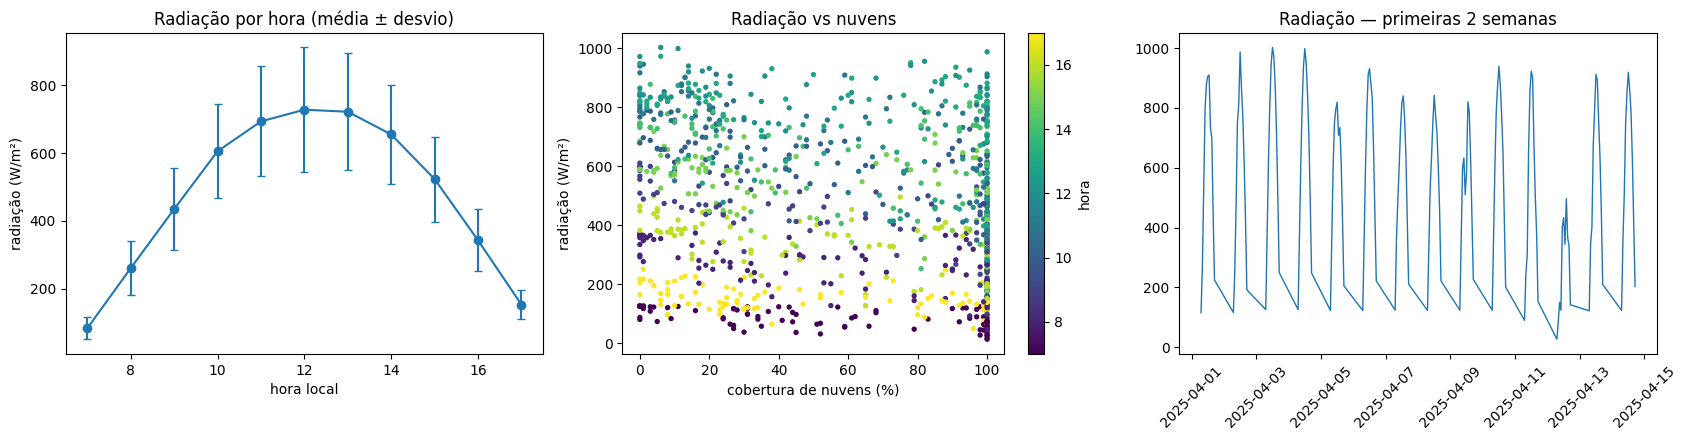

temperatura_c    0.64
umidade_pct     -0.60
nuvens_pct      -0.18
vento_kmh       -0.23
hora             0.12
radiacao_w_m2    1.00
Name: radiacao_w_m2, dtype: float64


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# radiação média por hora
por_hora = df_reg.groupby("hora")["radiacao_w_m2"].agg(["mean", "std"])
axes[0].errorbar(por_hora.index, por_hora["mean"], yerr=por_hora["std"], marker="o", capsize=3)
axes[0].set_xlabel("hora local"); axes[0].set_ylabel("radiação (W/m²)")
axes[0].set_title("Radiação por hora (média ± desvio)")

# radiação x nuvens
sc = axes[1].scatter(df_reg["nuvens_pct"], df_reg["radiacao_w_m2"], c=df_reg["hora"], s=8, cmap="viridis")
axes[1].set_xlabel("cobertura de nuvens (%)"); axes[1].set_ylabel("radiação (W/m²)")
axes[1].set_title("Radiação vs nuvens"); plt.colorbar(sc, ax=axes[1], label="hora")

# primeiras duas semanas
recorte = df_reg.iloc[:11 * 14]
axes[2].plot(recorte["data_hora"], recorte["radiacao_w_m2"], lw=1)
axes[2].set_title("Radiação — primeiras 2 semanas"); axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print(df_reg[["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"]]
      .corr()["radiacao_w_m2"].round(2))

**Leitura da exploração.** A base tem 1.001 linhas (91 dias com 11 horas cada) e não tem valores ausentes. A radiação média por hora forma um sino: uns 80 W/m² às 7h, pico de uns 730 W/m² entre 12h e 13h e volta para uns 150 W/m² às 17h. Em cada hora a variação entre os dias é grande (desvio de uns 140 a 185 W/m² no meio do dia), e isso precisa ser explicado pelas outras variáveis.

Nas correlações com a radiação, as maiores em módulo são temperatura (0,64) e umidade (−0,60), depois vento (−0,23), nuvens (−0,18) e hora (0,12). A correlação da hora é baixa porque a relação tem forma de sino, e a correlação mede só relação linear. As nuvens quase não aparecem no gráfico: mesmo com 100% de nuvens há horas com mais de 800 W/m². Então, nesses dados, a cobertura de nuvens explica pouco da radiação de cada hora.

## 2.2 Definição de X e y e divisão temporal (80% primeiras horas / 20% últimas)

In [22]:
features_reg = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X_reg = df_reg[features_reg]
y_reg = df_reg["radiacao_w_m2"]

corte = int(len(df_reg) * 0.80)  # sem embaralhar
Xr_train, Xr_test = X_reg.iloc[:corte], X_reg.iloc[corte:]
yr_train, yr_test = y_reg.iloc[:corte], y_reg.iloc[corte:]

print("Treino:", Xr_train.shape, df_reg["data_hora"].iloc[0], "->", df_reg["data_hora"].iloc[corte - 1])
print("Teste: ", Xr_test.shape,  df_reg["data_hora"].iloc[corte], "->", df_reg["data_hora"].iloc[-1])

Treino: (800, 5) 2025-04-01 07:00:00 -> 2025-06-12 14:00:00
Teste:  (201, 5) 2025-06-12 15:00:00 -> 2025-06-30 17:00:00


In [23]:
# médias no treino e no teste
comp = pd.DataFrame({"treino": [yr_train.mean(), Xr_train["nuvens_pct"].mean(), Xr_train["temperatura_c"].mean()],
                     "teste":  [yr_test.mean(),  Xr_test["nuvens_pct"].mean(),  Xr_test["temperatura_c"].mean()]},
                    index=["radiação média (W/m²)", "nuvens média (%)", "temperatura média (°C)"]).round(1)
comp

,treino,teste
radiação média (W/m²),497.8,373.4
nuvens média (%),51.8,68.4
temperatura média (°C),29.5,26.5


## 2.3 Treino dos três regressores

A Regressão Linear é a referência mais simples (com padronização dentro do Pipeline), mas só representa relações lineares, e a radiação tem forma de sino ao longo do dia. O Random Forest e o Gradient Boosting conseguem representar relações que não são lineares, como hora junto com nuvens. Escolhi os dois porque funcionam de jeitos diferentes: o Random Forest treina várias árvores separadas e o Gradient Boosting treina uma depois da outra, cada uma tentando corrigir o erro da anterior.

Os três usam a mesma divisão temporal: as primeiras 80% das horas para treino e as últimas 20% para teste, sem embaralhar.

In [24]:
modelos_reg = {
    "Regressão Linear": Pipeline([("scaler", StandardScaler()), ("modelo", LinearRegression())]),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
}

resultados_reg, previsoes_reg = [], {}
for nome, modelo in modelos_reg.items():
    modelo.fit(Xr_train, yr_train)
    pred = modelo.predict(Xr_test)
    previsoes_reg[nome] = pred
    resultados_reg.append({
        "Algoritmo": nome,
        "MAE (W/m²)": mean_absolute_error(yr_test, pred),
        "MSE ((W/m²)²)": mean_squared_error(yr_test, pred),
        "R²": r2_score(yr_test, pred),
    })

tabela_reg = pd.DataFrame(resultados_reg).set_index("Algoritmo").round(3)
print("Configuração: split temporal 80/20 sem embaralhar | treino =", len(Xr_train), "| teste =", len(Xr_test))
tabela_reg

Configuração: split temporal 80/20 sem embaralhar | treino = 800 | teste = 201


,MAE (W/m²),MSE ((W/m²)²),R²
Algoritmo,,,
Regressão Linear,145.205,30034.201,0.360
Random Forest,66.399,7210.084,0.846
Gradient Boosting,67.082,7444.700,0.841


In [25]:
# baseline (não conta como um dos três): sempre prevê a média do treino
base = DummyRegressor(strategy="mean").fit(Xr_train, yr_train)
pb = base.predict(Xr_test)
print("Baseline média do treino -> MAE: %.1f | R²: %.3f" % (mean_absolute_error(yr_test, pb), r2_score(yr_test, pb)))

Baseline média do treino -> MAE: 209.0 | R²: -0.330


## 2.4 Valores reais × previstos

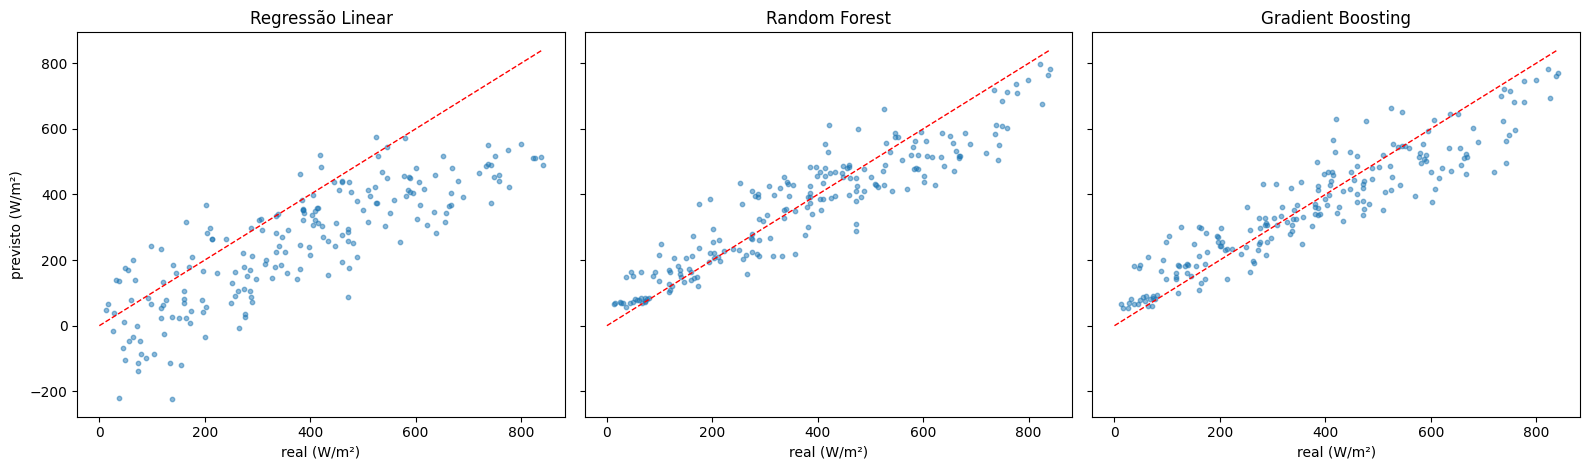

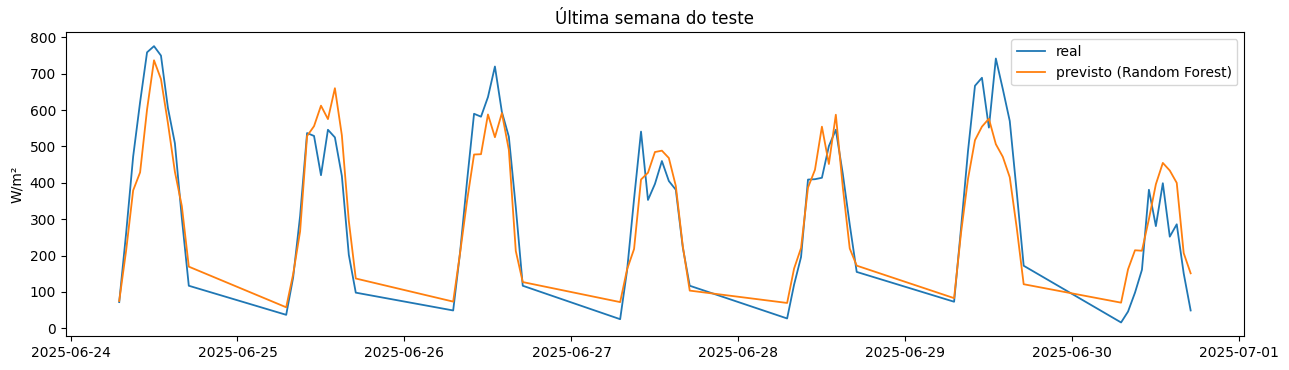

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
lim = [0, max(yr_test.max(), max(p.max() for p in previsoes_reg.values()))]
for ax, (nome, pred) in zip(axes, previsoes_reg.items()):
    ax.scatter(yr_test, pred, s=10, alpha=0.5)
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_title(nome); ax.set_xlabel("real (W/m²)")
axes[0].set_ylabel("previsto (W/m²)")
plt.tight_layout(); plt.show()

melhor_reg = tabela_reg["MAE (W/m²)"].idxmin()
datas_teste = df_reg["data_hora"].iloc[corte:]
n = 11 * 7  # última semana do teste
plt.figure(figsize=(13, 3.8))
plt.plot(datas_teste.iloc[-n:], yr_test.iloc[-n:], label="real", lw=1.3)
plt.plot(datas_teste.iloc[-n:], previsoes_reg[melhor_reg][-n:], label=f"previsto ({melhor_reg})", lw=1.3)
plt.ylabel("W/m²"); plt.legend(); plt.title("Última semana do teste"); plt.tight_layout(); plt.show()

## 2.5 Peso da hora do dia

In [ ]:
# importância por permutação
modelo_ref = modelos_reg["Random Forest"]
imp = permutation_importance(modelo_ref, Xr_test, yr_test, n_repeats=10, random_state=SEED,
                             scoring="neg_mean_absolute_error")
imp_df = pd.Series(imp.importances_mean, index=features_reg).sort_values()
imp_df.plot.barh(figsize=(6, 3.5), title="Importância por permutação (Random Forest, ΔMAE em W/m²)")
plt.tight_layout(); plt.show()

# mesmo modelo sem a coluna hora
sem_hora = RandomForestRegressor(n_estimators=300, random_state=SEED)
cols = [c for c in features_reg if c != "hora"]
sem_hora.fit(Xr_train[cols], yr_train)
p = sem_hora.predict(Xr_test[cols])
print("Random Forest SEM hora -> MAE: %.1f | R²: %.3f" % (mean_absolute_error(yr_test, p), r2_score(yr_test, p)))
print("Random Forest COM hora -> MAE: %.1f | R²: %.3f" % (tabela_reg.loc["Random Forest", "MAE (W/m²)"],
                                                          tabela_reg.loc["Random Forest", "R²"]))

In [ ]:
# o que muda tirando variáveis (mesmo modelo, mesma divisão)
def testar(cols):
    m = RandomForestRegressor(n_estimators=300, random_state=SEED).fit(Xr_train[cols], yr_train)
    p = m.predict(Xr_test[cols])
    return round(mean_absolute_error(yr_test, p), 1), round(r2_score(yr_test, p), 3)

variacoes = {
    "todas as variáveis": features_reg,
    "sem hora": [f for f in features_reg if f != "hora"],
    "sem temperatura": [f for f in features_reg if f != "temperatura_c"],
    "sem hora e sem temperatura": [f for f in features_reg if f not in ("hora", "temperatura_c")],
    "só hora": ["hora"],
}
print(pd.DataFrame({k: testar(v) for k, v in variacoes.items()}, index=["MAE (W/m²)", "R²"]).T)

                            MAE (W/m²)     R²
todas as variáveis                66.4  0.846
sem hora                         131.4  0.337
sem temperatura                   63.2  0.822
sem hora e sem temperatura       127.1  0.270
só hora                          131.8  0.289


## 2.6 Interpretação — Tarefa 2

1. Melhor modelo. O Random Forest teve o menor erro (MAE 66,4 W/m² e R² 0,846), mas o Gradient Boosting ficou quase igual (67,1 e 0,841). A diferença de 0,7 W/m² é pequena demais, e com uma divisão só não dá para dizer que um é melhor. Os dois foram bem melhores que a Regressão Linear (MAE 145,2 e R² 0,360) e que o baseline da média (MAE 209,0 e R² −0,330). A linear vai pior porque a radiação tem forma de sino ao longo do dia e uma reta não consegue seguir isso. No gráfico de real contra previsto, ela erra para menos nos valores altos e chega a prever radiação negativa (perto de −200 W/m²), o que não faz sentido.

2. Onde estão os erros. Nos gráficos de real contra previsto, os modelos de árvore ficam abaixo da diagonal nos valores reais mais altos (acima de 600 W/m²), ou seja, erram para menos nos picos, e quase nunca preveem valores perto de zero (o mínimo previsto fica entre 60 e 70 W/m²). Árvores não conseguem prever valores fora do que viram no treino. O R² negativo do baseline mostra que a média do treino não serve para o período de teste (12 a 30 de junho). A célula da seção 2.2 confirma isso: a radiação média cai de 497,8 para 373,4 W/m² (uns 25% a menos), as nuvens sobem de 51,8% para 68,4% e a temperatura cai de 29,5 para 26,5 °C. Ou seja, o fim de junho foi mais nublado e mais frio, o que combina com o inverno. Com só três meses de dados não dá para separar o que é estação do ano do que foi o tempo daquelas semanas. Também achei interessante que, hora a hora, a nuvem tem pouca relação com a radiação (correlação de −0,18), mas o período de teste, que foi mais nublado, teve radiação média bem menor.

3. Papel da hora. A hora é a variável mais importante. Na importância por permutação do Random Forest, embaralhar a hora piora o MAE em cerca de 100 W/m², contra uns 53 da temperatura, 23 da umidade, 13 das nuvens e 1 do vento. Quando tirei a hora do modelo, o MAE foi de 66,4 para 131,4 W/m² e o R² de 0,846 para 0,337. Isso mostra que a correlação de 0,12 enganava, já que a relação é em forma de sino. Também testei tirar variáveis do modelo (célula logo depois do gráfico). Sem a hora o R² é 0,337, e sem hora e sem temperatura cai para 0,270, então a temperatura ajuda um pouco quando a hora não está, mas a maior parte do que o modelo sem a hora acerta vem de umidade, nuvens e vento. Com a hora no modelo, tirar a temperatura quase não muda o resultado (R² de 0,846 para 0,822), então ela é em boa parte repetida em relação à hora. Por isso a temperatura aparece com peso alto na importância por permutação, mas tirar ela do modelo quase não piora. Usando só a hora o R² é 0,289, então o bom resultado vem da hora junto com as outras variáveis.

4. Radiação não é geração de energia. A radiação é a energia do sol que chega na superfície, e a geração de um painel depende de coisas que não estão nos dados: eficiência do painel e do inversor, temperatura do painel, inclinação, sombra, sujeira e perdas. Os dados também são de modelo (reanálise) e não de medição no local. Além disso, W/m² é potência em um instante, e a energia gerada (kWh) precisa somar isso ao longo do tempo e considerar a área e a eficiência do painel. Um bom modelo de radiação ajuda a estimar o potencial solar, mas não diz quanto uma usina vai produzir.

---
# Resumo final das seis comparações

In [ ]:
print("Resumo Tarefa 1"); display(tabela_clf)
print("Resumo Tarefa 2"); display(tabela_reg)

# Conclusão geral

Tarefa 1. Os três classificadores separaram bem Solar, Eólica e Hidráulica só com potência e coordenadas (acurácia de 0,94 a 0,98, contra 0,38 do baseline), e o Random Forest ficou um pouco à frente do KNN. A Solar foi a classe mais confundida. A amostra não é aleatória e tem problemas (62,8% da Solar com até 1 kW e 47 linhas com coordenadas zero), mas tirar esses casos diminuiu o F1 macro em só 2 a 3 pontos (RF de 0,975 para 0,955) e a ordem dos modelos continuou igual. As coordenadas repetidas da Solar (46%) merecem atenção, mas só 28 linhas são duplicatas exatas. Com mais tempo, eu pegaria uma amostra aleatória do cadastro inteiro, separaria os empreendimentos por fase e testaria mais de um split.

Tarefa 2. O Random Forest e o Gradient Boosting explicam uns 84% a 85% da variação da radiação no teste e reduzem o erro do baseline de 209 para uns 66 W/m². A hora do dia foi o fator mais importante: sem ela o R² cai de 0,85 para 0,34. A Regressão Linear foi mal porque não segue a forma de sino. As limitações são a diferença entre o período de treino e o de teste, o fato de os dados serem de reanálise e a distância entre radiação e geração de energia. Com mais dados, eu usaria mais de um ano para cobrir todas as estações e testaria variáveis como o ângulo do sol.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)